In [18]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [21]:
import pandas as pd

df=pd.read_csv("train.csv")
print(df.shape)
print(df.info())

(1460, 81)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 1

In [22]:
print(df.columns.tolist())

['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC'

              Missing Count    Percent
PoolQC                 1453  99.520548
MiscFeature            1406  96.301370
Alley                  1369  93.767123
Fence                  1179  80.753425
MasVnrType              872  59.726027
FireplaceQu             690  47.260274
LotFrontage             259  17.739726
GarageQual               81   5.547945
GarageFinish             81   5.547945
GarageType               81   5.547945
GarageYrBlt              81   5.547945
GarageCond               81   5.547945
BsmtFinType2             38   2.602740
BsmtExposure             38   2.602740
BsmtCond                 37   2.534247
BsmtQual                 37   2.534247
BsmtFinType1             37   2.534247
MasVnrArea                8   0.547945
Electrical                1   0.068493


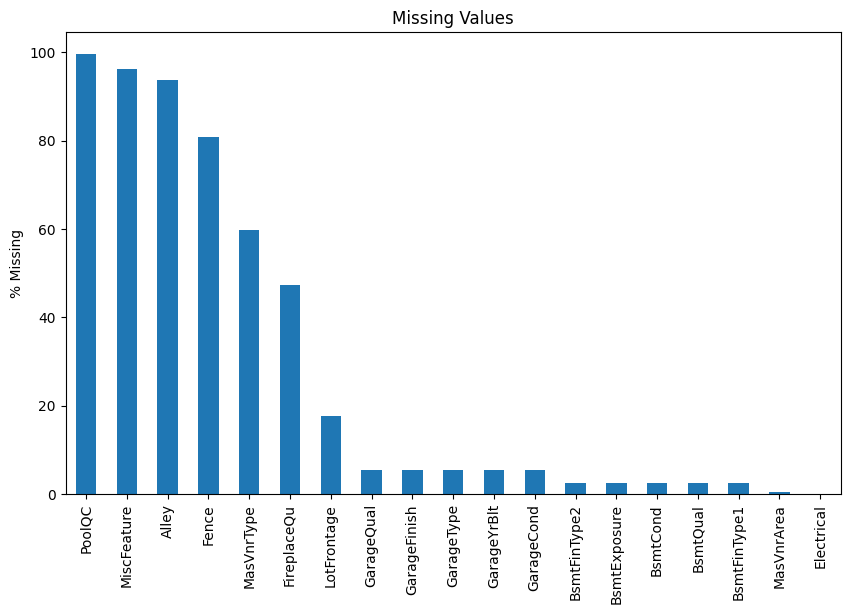

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing/len(df))*100
missing_df = pd.DataFrame({"Missing Count":missing,"Percent": missing_percent})
print(missing_df[missing_df["Missing Count"]>0])

plt.figure(figsize=(10,6))
missing_percent[missing_percent > 0].plot(kind="bar")
plt.title("Missing Values")
plt.ylabel("% Missing")
plt.show()


In [24]:
cols_fill_none = ["Alley", "MasVnrType", "FireplaceQu", "GarageType",
                   "GarageFinish", "GarageQual", "GarageCond",
                   "BsmtQual", "BsmtCond", "BsmtExposure",
                   "BsmtFinType1", "BsmtFinType2", "PoolQC",
                   "Fence", "MiscFeature"]

for col in cols_fill_none:
    df[col] = df[col].fillna("None")

In [25]:
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())

In [26]:
print(df.isnull().sum().sum())
remaining_missing= df.isnull().sum()
print(remaining_missing[remaining_missing>0])

90
MasVnrArea      8
Electrical      1
GarageYrBlt    81
dtype: int64


In [27]:
cols_fill_none = ["Alley", "MasVnrType", "FireplaceQu", "GarageType",
                   "GarageFinish", "GarageQual", "GarageCond",
                   "BsmtQual", "BsmtCond", "BsmtExposure",
                   "BsmtFinType1", "BsmtFinType2", "PoolQC",
                   "Fence", "MiscFeature"]

for col in cols_fill_none:
    if col in df.columns:
        df[col] = df[col].fillna("None")

df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())

df["GarageYrBlt"] = df["GarageYrBlt"].fillna(df["GarageYrBlt"].median())

df["MasVnrArea"] = df["MasVnrArea"].fillna(df["MasVnrArea"].median())

df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

print(df.isnull().sum().sum())

0


In [16]:
print(df.columns.tolist())

['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC'

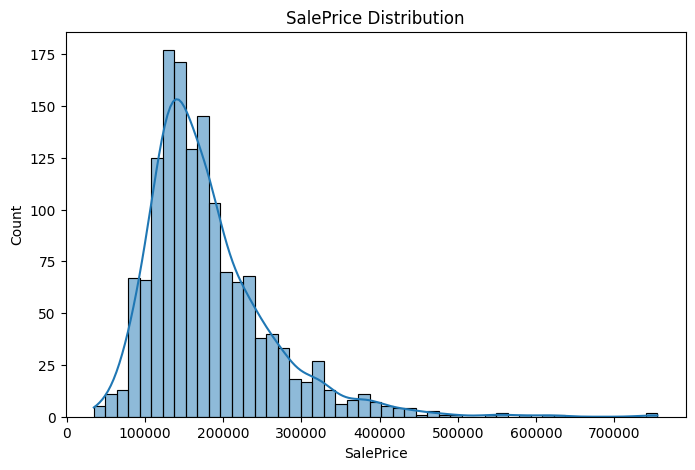

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


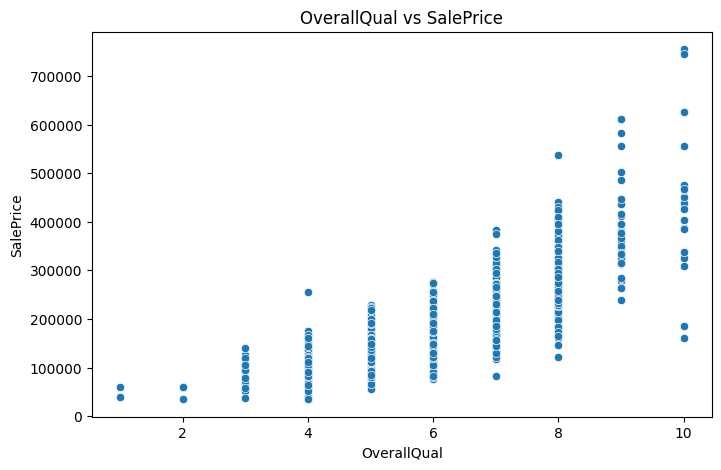

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(df["SalePrice"], kde=True)
plt.title("SalePrice Distribution")
plt.show()
numeric_df = df.select_dtypes(include=["int64", "float64"])
correlations = numeric_df.corr()["SalePrice"].sort_values(ascending=False)
print(correlations.head(11))
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["OverallQual"], y=df["SalePrice"])
plt.title("OverallQual vs SalePrice")
plt.show()

Skewness before: 1.8828757597682129


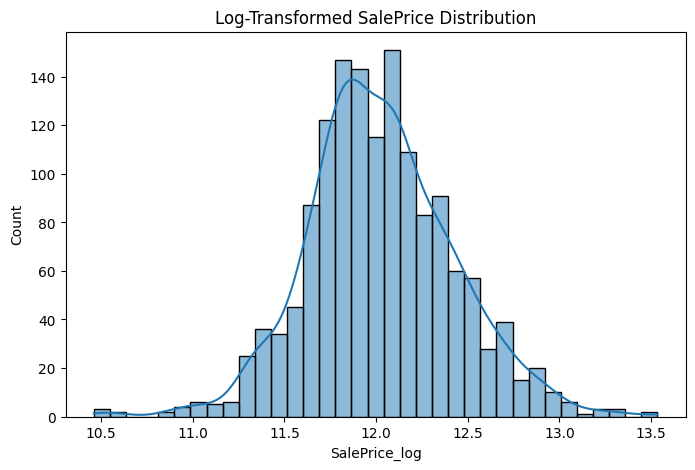

Skewness after: 0.12134661989685333


In [29]:
import numpy as np

print("Skewness before:", df["SalePrice"].skew())

df["SalePrice_log"] = np.log1p(df["SalePrice"])


plt.figure(figsize=(8,5))
sns.histplot(df["SalePrice_log"], kde=True)
plt.title("Log-Transformed SalePrice Distribution")
plt.show()

print("Skewness after:", df["SalePrice_log"].skew())

In [30]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
correlations = numeric_df.corr()["SalePrice_log"].sort_values(ascending=False)
print(correlations.head(11))

SalePrice_log    1.000000
SalePrice        0.948374
OverallQual      0.817185
GrLivArea        0.700927
GarageCars       0.680625
GarageArea       0.650888
TotalBsmtSF      0.612134
1stFlrSF         0.596981
FullBath         0.594771
YearBuilt        0.586570
YearRemodAdd     0.565608
Name: SalePrice_log, dtype: float64


In [31]:

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
print(categorical_cols)
print("Total categorical columns:", len(categorical_cols))

['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
Total categorical columns: 43


In [32]:
quality_map = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "None": 0}

ordinal_cols = ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond",
                "HeatingQC", "KitchenQual", "FireplaceQu",
                "GarageQual", "GarageCond", "PoolQC"]

for col in ordinal_cols:
    df[col] = df[col].map(quality_map)

In [33]:
nominal_cols = ["MSZoning", "Street", "Alley", "LotShape", "LandContour",
                "Utilities", "LotConfig", "LandSlope", "Neighborhood",
                "Condition1", "Condition2", "BldgType", "HouseStyle",
                "RoofStyle", "RoofMatl", "Exterior1st", "Exterior2nd",
                "MasVnrType", "Foundation", "BsmtExposure", "BsmtFinType1",
                "BsmtFinType2", "Heating", "CentralAir", "Electrical",
                "Functional", "GarageType", "GarageFinish", "PavedDrive",
                "Fence", "MiscFeature", "SaleType", "SaleCondition"]

df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
print(df.shape)

(1460, 232)


In [34]:
print(df.isnull().sum().sum())


0


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(["SalePrice", "SalePrice_log", "Id"], axis=1)
y = df["SalePrice_log"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape, X_test_scaled.shape)

(1168, 229) (292, 229)


In [36]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import cross_val_score
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    test_score = model.score(X_test_scaled, y_test)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="r2")
    results[name] = {"Test R2": test_score, "CV Mean R2": cv_scores.mean()}
    print(f"{name}: Test R2 = {test_score:.4f}, CV Mean R2 = {cv_scores.mean():.4f}")

Linear Regression: Test R2 = 0.7719, CV Mean R2 = 0.7355
Ridge: Test R2 = 0.7913, CV Mean R2 = 0.7539
Lasso: Test R2 = 0.8439, CV Mean R2 = 0.8018


In [37]:
lasso_model = models["Lasso"]
coefficients = pd.Series(lasso_model.coef_, index=X.columns)

zero_features = (coefficients == 0).sum()
print(f"Total features: {len(coefficients)}")
print(f"Features set to zero by Lasso: {zero_features}")

print(coefficients.abs().sort_values(ascending=False).head(10))

Total features: 229
Features set to zero by Lasso: 59
RoofMatl_CompShg    0.208581
RoofMatl_Tar&Grv    0.148655
GrLivArea           0.111020
RoofMatl_WdShngl    0.100554
RoofMatl_WdShake    0.083781
OverallQual         0.068252
YearBuilt           0.052769
RoofMatl_Metal      0.049277
RoofMatl_Roll       0.048354
OverallCond         0.040167
dtype: float64


In [38]:
print(df["RoofMatl_CompShg"].sum())
print(df["RoofMatl_WdShngl"].sum())
print(df["RoofMatl_Roll"].sum())

1434
6
1


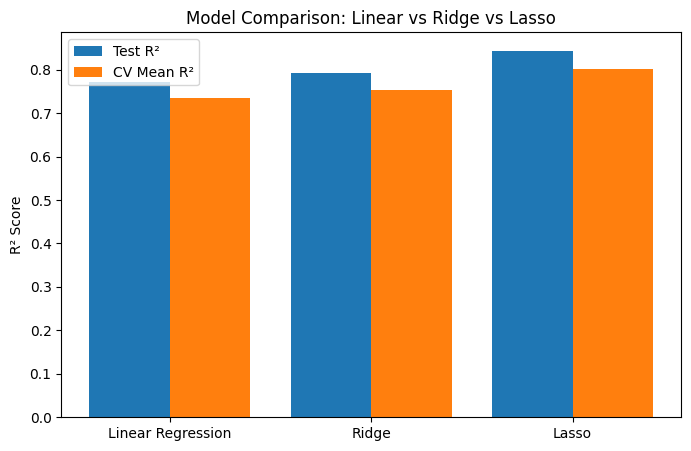

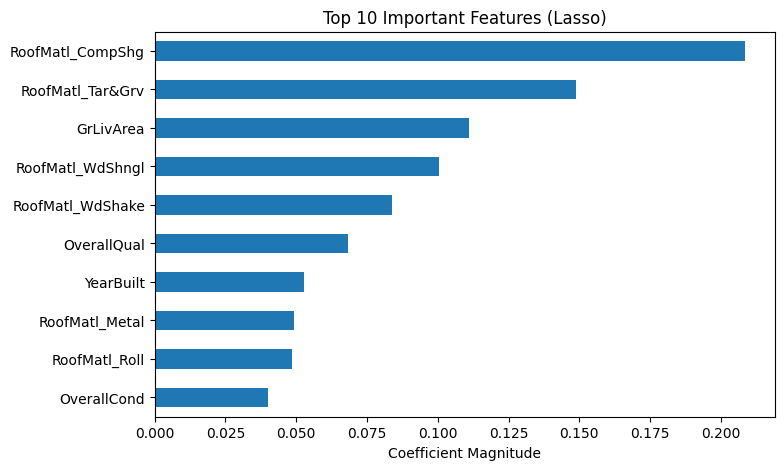

In [39]:

model_names = list(results.keys())
test_scores = [results[m]["Test R2"] for m in model_names]
cv_scores_list = [results[m]["CV Mean R2"] for m in model_names]

x = range(len(model_names))
plt.figure(figsize=(8,5))
plt.bar([i-0.2 for i in x], test_scores, width=0.4, label="Test R²")
plt.bar([i+0.2 for i in x], cv_scores_list, width=0.4, label="CV Mean R²")
plt.xticks(x, model_names)
plt.ylabel("R² Score")
plt.title("Model Comparison: Linear vs Ridge vs Lasso")
plt.legend()
plt.show()

top_features = lasso_model.coef_
top_10 = pd.Series(top_features, index=X.columns).abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top_10.plot(kind="barh")
plt.title("Top 10 Important Features (Lasso)")
plt.xlabel("Coefficient Magnitude")
plt.gca().invert_yaxis()
plt.show()